In [1]:
import geopandas as gpd
# from urllib.parse import urlencode
import pandas as pd
from pathlib import Path
import requests
import folium

In [45]:
OUTPUT_DIR = Path("../data/JC")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

geojson_url = "https://raw.githubusercontent.com/hovhannisyan91/aca/main/lab/python/data/citibike/JC/jersey-city-neighborhoods.geojson"

output_file = OUTPUT_DIR / "jersey-city-neighborhoods.geojson"

response = requests.get(geojson_url)
response.raise_for_status()

with open(output_file, "wb") as f:
    f.write(response.content)

print(f"Saved to: {output_file}")

Saved to: ../data/JC/jersey-city-neighborhoods.geojson


In [46]:
jersey_city = gpd.read_file(output_file)
jersey_city.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696..."
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700..."
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737..."
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ..."
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020..."


In [47]:
jersey_city.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   cartodb_id    53 non-null     int32   
 1   area_sq_ft    53 non-null     float64 
 2   acres         53 non-null     float64 
 3   area          53 non-null     str     
 4   neighborhood  53 non-null     str     
 5   color         18 non-null     float64 
 6   lon           53 non-null     float64 
 7   lat           53 non-null     float64 
 8   geometry      53 non-null     geometry
dtypes: float64(5), geometry(1), int32(1), str(2)
memory usage: 3.6 KB


In [48]:
jersey_city.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Axes: >

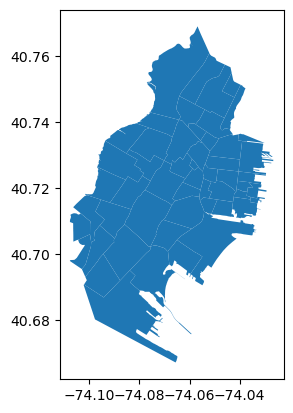

In [49]:
jersey_city.plot()

### Reading ride Data

In [2]:
citibike_df = pd.read_csv("../data/JC/JC2025_Enriched.csv")

In [58]:
citibike_df

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration_minutes,date,month,month_name,day_of_week,hour,season
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,13.307467,2025-11-18,2025-11,November,Tuesday,18,Autumn
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,14.495367,2025-11-26,2025-11,November,Wednesday,16,Autumn
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,40.740802,-74.042521,member,6.983450,2025-11-04,2025-11,November,Tuesday,22,Autumn
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,5.803383,2025-11-08,2025-11,November,Saturday,6,Autumn
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,6.658383,2025-11-24,2025-11,November,Monday,20,Autumn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
998276,6E94923FE2C0FF31,electric_bike,2025-08-31 01:07:38.410,2025-08-31 01:10:48.312,Hilltop,JC019,Oakland Ave,JC022,40.731169,-74.057574,40.737604,-74.052478,member,3.165033,2025-08-31,2025-08,August,Sunday,1,Summer
998277,BBE94D32AA492DA8,electric_bike,2025-08-06 17:14:05.249,2025-08-06 17:26:19.124,River St & Newark St,HB106,Stevens - River Ter & 6 St,HB602,40.736722,-74.029007,40.743133,-74.026989,member,12.231250,2025-08-06,2025-08,August,Wednesday,17,Summer
998278,68D356CA1B595A75,electric_bike,2025-08-18 00:56:54.543,2025-08-18 01:00:15.680,Stevens - River Ter & 6 St,HB602,Stevens - River Ter & 6 St,HB602,40.743133,-74.026989,40.743133,-74.026989,member,3.352283,2025-08-18,2025-08,August,Monday,0,Summer
998279,8B55D76CD09DB7E2,electric_bike,2025-08-08 21:14:26.007,2025-08-08 21:22:04.620,Stevens - River Ter & 6 St,HB602,Stevens - River Ter & 6 St,HB602,40.743133,-74.026989,40.743133,-74.026989,member,7.643550,2025-08-08,2025-08,August,Friday,21,Summer


### Station Departures

In [52]:
start_stations = citibike_df[
    [
        "ride_id",
        "start_station_id",
        "start_station_name",
        "start_lat",
        "start_lng"
    ]
].copy()

In [53]:
start_stations = start_stations.rename(
    columns={
        "start_station_id": "station_id",
        "start_station_name": "station_name",
        "start_lat": "lat",
        "start_lng": "lng"
    }
)

start_stations["activity_type"] = "departure"

### Station Arrivals

In [54]:
end_stations = citibike_df[
    [
        "ride_id",
        "end_station_id",
        "end_station_name",
        "end_lat",
        "end_lng"
    ]
].copy()

end_stations = end_stations.rename(
    columns={
        "end_station_id": "station_id",
        "end_station_name": "station_name",
        "end_lat": "lat",
        "end_lng": "lng"
    }
)

end_stations["activity_type"] = "arrival"

end_stations.head()

,ride_id,station_id,station_name,lat,lng,activity_type
0,9F734BE1BFC45FF4,JC131,West Side Ave & Stegman Pkwy,40.710870,-74.093680,arrival
1,B6C773B13AC0E465,JC131,West Side Ave & Stegman Pkwy,40.710870,-74.093680,arrival
2,C300465AA158280F,HB408,Marshall St & 2 St,40.740802,-74.042521,arrival
3,31A424FC97C8AAFB,HB408,Marshall St & 2 St,40.740802,-74.042521,arrival
4,08C5EA04CB1FDC57,HB408,Marshall St & 2 St,40.740802,-74.042521,arrival


### Concatenate Departures and Arrivals

In [55]:
station_activity_long = pd.concat(
    [
        start_stations,
        end_stations
    ],
    ignore_index=True
)

station_activity_long = station_activity_long.dropna(
    subset=[
        "station_id",
        "station_name",
        "lat",
        "lng"
    ]
)

station_activity_long.head()

,ride_id,station_id,station_name,lat,lng,activity_type
0,9F734BE1BFC45FF4,JC094,Glenwood Ave,40.727551,-74.071061,departure
1,B6C773B13AC0E465,JC094,Glenwood Ave,40.727551,-74.071061,departure
2,C300465AA158280F,HB203,Bloomfield St & 15 St,40.754530,-74.026580,departure
3,31A424FC97C8AAFB,HB303,Clinton St & 7 St,40.745420,-74.033320,departure
4,08C5EA04CB1FDC57,HB303,Clinton St & 7 St,40.745420,-74.033320,departure


### Cleaning and Aggregating

In [56]:
station_activity_agg = (
    station_activity_long
    .groupby(
        [
            "station_id",
            "station_name",
            "lat",
            "lng",
            "activity_type"
        ],
        as_index=False
    )
    .agg(
        number_of_rides=("ride_id", "count")
    )
)

station_activity_agg.head()

,station_id,station_name,lat,lng,activity_type,number_of_rides
0,3278.07,Brooklyn Ave & Snyder Ave,40.649150,-73.943680,arrival,1
1,3344.02,Park Circle & East Dr,40.651566,-73.972212,arrival,1
2,3480.04,Parkside Ave & Flatbush Ave,40.655630,-73.959680,arrival,1
3,3579.04,Windsor Pl & Howard Pl,40.659491,-73.980139,arrival,1
4,3762.08,10 St & 7 Ave,40.666208,-73.981999,arrival,1


### Pivot the Data

In [57]:
station_summary = (
    station_activity_agg
    .pivot_table(
        index=[
            "station_id",
            "station_name",
            "lat",
            "lng"
        ],
        columns="activity_type",
        values="number_of_rides",
        fill_value=0
    )
    .reset_index()
)

station_summary.head()

activity_type,station_id,station_name,lat,lng,arrival,departure
0,3278.07,Brooklyn Ave & Snyder Ave,40.649150,-73.943680,1.0,0.0
1,3344.02,Park Circle & East Dr,40.651566,-73.972212,1.0,0.0
2,3480.04,Parkside Ave & Flatbush Ave,40.655630,-73.959680,1.0,0.0
3,3579.04,Windsor Pl & Howard Pl,40.659491,-73.980139,1.0,0.0
4,3762.08,10 St & 7 Ave,40.666208,-73.981999,1.0,0.0


### Rename and Create Final Metrics

In [59]:
station_summary = station_summary.rename(
    columns={
        "departure": "total_departures",
        "arrival": "total_arrivals"
    }
)

station_summary["total_activity"] = (
    station_summary["total_departures"] +
    station_summary["total_arrivals"]
)

station_summary["net_departures"] = (
    station_summary["total_departures"] -
    station_summary["total_arrivals"]
)

station_summary = station_summary.sort_values(
    "total_activity",
    ascending=False
).reset_index(drop=True)

station_summary.head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_departures
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,44984.0,92728.0,-2760.0
1,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,26638.0,25879.0,52517.0,-759.0
2,JC009,Hamilton Park,40.727596,-74.044247,22347.0,22232.0,44579.0,-115.0
3,HB106,River St & Newark St,40.736722,-74.029007,22113.0,21383.0,43496.0,-730.0
4,JC066,Newport PATH,40.727224,-74.033759,20698.0,20641.0,41339.0,-57.0


In [61]:
station_gdf = gpd.GeoDataFrame(
    station_summary,
    geometry=gpd.points_from_xy(
        station_summary["lng"],
        station_summary["lat"]
    ),
    crs="EPSG:4326"
)

station_gdf.head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_departures,geometry
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,44984.0,92728.0,-2760.0,POINT (-74.04309 40.71941)
1,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,26638.0,25879.0,52517.0,-759.0,POINT (-74.0303 40.73594)
2,JC009,Hamilton Park,40.727596,-74.044247,22347.0,22232.0,44579.0,-115.0,POINT (-74.04425 40.7276)
3,HB106,River St & Newark St,40.736722,-74.029007,22113.0,21383.0,43496.0,-730.0,POINT (-74.02901 40.73672)
4,JC066,Newport PATH,40.727224,-74.033759,20698.0,20641.0,41339.0,-57.0,POINT (-74.03376 40.72722)


<Axes: >

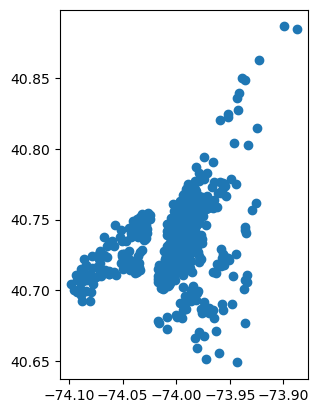

In [62]:
station_gdf.plot()

### Top Ride Lines

In [63]:
route_summary = (
    citibike_df
    .dropna(
        subset=[
            "start_station_id",
            "start_station_name",
            "end_station_id",
            "end_station_name",
            "start_lat",
            "start_lng",
            "end_lat",
            "end_lng"
        ]
    )
    .groupby(
        [
            "start_station_id",
            "start_station_name",
            "end_station_id",
            "end_station_name",
            "start_lat",
            "start_lng",
            "end_lat",
            "end_lng"
        ],
        as_index=False
    )
    .agg(
        number_of_rides=("ride_id", "count")
    )
    .sort_values("number_of_rides", ascending=False)
)

route_summary["route"] = (
    route_summary["start_station_name"] +
    " → " +
    route_summary["end_station_name"]
)

route_summary.head()

,start_station_id,start_station_name,end_station_id,end_station_name,start_lat,start_lng,end_lat,end_lng,number_of_rides,route
83,HB101,Hoboken Terminal - Hudson St & Hudson Pl,JC105,Hoboken Ave at Monmouth St,40.735938,-74.030305,40.735208,-74.046964,4559,Hoboken Terminal - Hudson St & Hudson Pl → Hob...
5583,JC055,McGinley Square,JC109,Bergen Ave & Sip Ave,40.725340,-74.067622,40.731009,-74.064437,4306,McGinley Square → Bergen Ave & Sip Ave
8709,JC115,Grove St PATH,JC013,Marin Light Rail,40.719410,-74.043090,40.714584,-74.042817,4131,Grove St PATH → Marin Light Rail
3937,JC013,Marin Light Rail,JC115,Grove St PATH,40.714584,-74.042817,40.719410,-74.043090,3831,Marin Light Rail → Grove St PATH
8723,JC115,Grove St PATH,JC052,Liberty Light Rail,40.719410,-74.043090,40.711242,-74.055701,3750,Grove St PATH → Liberty Light Rail


### Inspect Top Routes

In [64]:
top_routes = route_summary.head(20)

top_routes[
    [
        "route",
        "number_of_rides"
    ]
]

,route,number_of_rides
83,Hoboken Terminal - Hudson St & Hudson Pl → Hob...,4559
5583,McGinley Square → Bergen Ave & Sip Ave,4306
8709,Grove St PATH → Marin Light Rail,4131
3937,Marin Light Rail → Grove St PATH,3831
8723,Grove St PATH → Liberty Light Rail,3750
8445,Bergen Ave & Sip Ave → McGinley Square,3609
5395,Liberty Light Rail → Grove St PATH,3605
8154,Hoboken Ave at Monmouth St → Hoboken Terminal ...,3257
4570,Brunswick St → Grove St PATH,3175
3788,Hamilton Park → Grove St PATH,2998


### Drawing Top Lines

In [66]:
top_lines = route_summary.head(100).copy()

center_lat = station_gdf["lat"].mean()
center_lng = station_gdf["lng"].mean()

line_map = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=12
)

max_rides = top_lines["number_of_rides"].max()

for _, row in top_lines.iterrows():

    start_point = [
        row["start_lat"],
        row["start_lng"]
    ]

    end_point = [
        row["end_lat"],
        row["end_lng"]
    ]

    line_weight = 1 + (row["number_of_rides"] / max_rides) * 8

    folium.PolyLine(
        locations=[start_point, end_point],
        weight=line_weight,
        opacity=0.5,
        popup=f"""
        <b>{row['route']}</b><br>
        Number of Rides: {row['number_of_rides']}
        """
    ).add_to(line_map)

line_map

### Spatial Join Between Stations and Neighborhoods

In [67]:
print("Station CRS:", station_gdf.crs)
print("Neighborhood CRS:", jersey_city.crs)

Station CRS: EPSG:4326
Neighborhood CRS: EPSG:4326


In [68]:
station_gdf = station_gdf.to_crs("EPSG:4326")
jersey_city = jersey_city.to_crs("EPSG:4326")

In [69]:
jersey_city.columns

Index(['cartodb_id', 'area_sq_ft', 'acres', 'area', 'neighborhood', 'color',
       'lon', 'lat', 'geometry'],
      dtype='str')

In [70]:
station_neighborhood = gpd.sjoin(
    station_gdf,
    jersey_city,
    how="inner",
    predicate="within"
)

station_neighborhood.head()

,station_id,station_name,lat_left,lng,total_arrivals,total_departures,total_activity,net_departures,geometry,index_right,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat_right
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,44984.0,92728.0,-2760.0,POINT (-74.04309 40.71941),49,2,411601381.8,9449.068,Downtown,Van Vorst Park,21.0,-74.047234,40.718943
2,JC009,Hamilton Park,40.727596,-74.044247,22347.0,22232.0,44579.0,-115.0,POINT (-74.04425 40.7276),10,18,411601381.8,9449.068,Downtown,Hamilton Park,28.0,-74.046672,40.727436
4,JC066,Newport PATH,40.727224,-74.033759,20698.0,20641.0,41339.0,-57.0,POINT (-74.03376 40.72722),8,12,411601381.8,9449.068,Downtown,Newport,22.0,-74.034927,40.729255
5,JC109,Bergen Ave & Sip Ave,40.731009,-74.064437,20357.0,20370.0,40727.0,13.0,POINT (-74.06444 40.73101),16,31,411601381.8,9449.068,Journal Square,Journal Square,NaN,-74.063466,40.733757
6,JC116,Exchange Pl,40.716366,-74.034344,20142.0,19982.0,40124.0,-160.0,POINT (-74.03434 40.71637),48,13,411601381.8,9449.068,Downtown,Exchange Place,23.0,-74.033539,40.716458


### Number of Stations 

In [71]:
print("All stations:", len(station_gdf))
print("Stations inside Jersey City neighborhoods:", len(station_neighborhood))

All stations: 488
Stations inside Jersey City neighborhoods: 79


### Neighborhood-Level Summary

In [72]:
neighborhood_activity = (
    station_neighborhood
    .groupby('neighborhood', as_index=False)
    .agg(
        number_of_stations=("station_id", "nunique"),
        total_departures=("total_departures", "sum"),
        total_arrivals=("total_arrivals", "sum"),
        total_activity=("total_activity", "sum"),
        net_departures=("net_departures", "sum")
    )
)

neighborhood_activity["avg_activity_per_station"] = (
    neighborhood_activity["total_activity"] /
    neighborhood_activity["number_of_stations"]
)

neighborhood_activity = neighborhood_activity.sort_values(
    "total_activity",
    ascending=False
)

neighborhood_activity.head()

,neighborhood,number_of_stations,total_departures,total_arrivals,total_activity,net_departures,avg_activity_per_station
25,Van Vorst Park,6,96144.0,98853.0,194997.0,-2709.0,32499.500000
17,Palus Hook,6,59496.0,59160.0,118656.0,336.0,19776.000000
14,Newport,2,39350.0,39402.0,78752.0,-52.0,39376.000000
10,Journal Square,3,32970.0,32560.0,65530.0,410.0,21843.333333
4,Hamilton Park,2,31729.0,31922.0,63651.0,-193.0,31825.500000


### Center Point

In [73]:
center_lat = station_gdf.geometry.y.mean()
center_lng = station_gdf.geometry.x.mean()

center_lat, center_lng

(np.float64(40.7340122586309), np.float64(-74.00137516113631))

In [74]:
station_point_map = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=12
)

for _, row in station_gdf.iterrows():

    folium.CircleMarker(
        location=[
            row.geometry.y,
            row.geometry.x
        ],
        radius=5,
        popup=f"""
        <b>{row['station_name']}</b><br>
        Station ID: {row['station_id']}<br>
        Departures: {row['total_departures']:.0f}<br>
        Arrivals: {row['total_arrivals']:.0f}<br>
        Total Activity: {row['total_activity']:.0f}<br>
        Net Departures: {row['net_departures']:.0f}
        """,
        tooltip=row["station_name"],
        fill=True,
        fill_opacity=0.6,
        opacity=0.8
    ).add_to(station_point_map)

station_point_map

### Merge Neighborhood Metrics Back to Polygons

In [75]:
neighborhood_choropleth_gdf = jersey_city.merge(
    neighborhood_activity,
    on='neighborhood',
    how="left"
)

neighborhood_choropleth_gdf.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry,number_of_stations,total_departures,total_arrivals,total_activity,net_departures,avg_activity_per_station
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696...",1.0,12.0,9.0,21.0,3.0,21.0000
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700...",NaN,NaN,NaN,NaN,NaN,NaN
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737...",NaN,NaN,NaN,NaN,NaN,NaN
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ...",6.0,30845.0,30730.0,61575.0,115.0,10262.5000
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020...",16.0,6142.0,6045.0,12187.0,97.0,761.6875


Some neighborhoods may not have Citi Bike stations.

For those neighborhoods, the activity values will be missing.

We replace missing values with zero.



In [76]:
activity_columns = [
    "number_of_stations",
    "total_departures",
    "total_arrivals",
    "total_activity",
    "net_departures",
    "avg_activity_per_station"
]

neighborhood_choropleth_gdf[activity_columns] = (
    neighborhood_choropleth_gdf[activity_columns]
    .fillna(0)
)

neighborhood_choropleth_gdf[
    [
        'neighborhood',
        "number_of_stations",
        "total_departures",
        "total_arrivals",
        "total_activity",
        "avg_activity_per_station"
    ]
].head()

,neighborhood,number_of_stations,total_departures,total_arrivals,total_activity,avg_activity_per_station
0,Port Liberte,1.0,12.0,9.0,21.0,21.0000
1,LSP Industrial,0.0,0.0,0.0,0.0,0.0000
2,Hackensack,0.0,0.0,0.0,0.0,0.0000
3,Lafayette,6.0,30845.0,30730.0,61575.0,10262.5000
4,Jackson Hill,16.0,6142.0,6045.0,12187.0,761.6875


### Choropleth Maps

In [77]:
def create_neighborhood_choropleth(
    gdf,
    metric,
    legend_name,
    neighborhood_col="neighborhood"
):
    choropleth_map = folium.Map(
        location=[center_lat, center_lng],
        zoom_start=12
    )

    folium.Choropleth(
        geo_data=gdf,
        data=gdf,
        columns=[neighborhood_col, metric],
        key_on=f"feature.properties.{neighborhood_col}",
        fill_opacity=0.7,
        line_opacity=0.4,
        legend_name=legend_name,
        nan_fill_opacity=0.1
    ).add_to(choropleth_map)

    folium.GeoJson(
        gdf,
        name="Neighborhood Boundaries",
        tooltip=folium.GeoJsonTooltip(
            fields=[
                neighborhood_col,
                metric
            ],
            aliases=[
                "Neighborhood:",
                f"{legend_name}:"
            ],
            localize=True
        ),
        style_function=lambda feature: {
            "fillOpacity": 0,
            "color": "black",
            "weight": 1
        }
    ).add_to(choropleth_map)

    folium.LayerControl().add_to(choropleth_map)

    return choropleth_map

### Total Activity by Neighborhood

In [ ]:
total_activity_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_activity",
    legend_name="Total Citi Bike Activity",
    neighborhood_col="neighborhood"
)

total_activity_map

### Choropleth by Number of Stations

In [79]:
station_count_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="number_of_stations",
    legend_name="Number of Citi Bike Stations",
    neighborhood_col="neighborhood"
)

station_count_map

### Choropleth by Average Activity per Station

In [80]:
avg_activity_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="avg_activity_per_station",
    legend_name="Average Activity per Station",
    neighborhood_col="neighborhood"
)

avg_activity_map

### Choropleth by Total Departures

In [81]:
departures_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_departures",
    legend_name="Total Departures",
    neighborhood_col="neighborhood"
)

departures_map

### Choropleth by Total Arrivals

In [82]:
arrivals_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_arrivals",
    legend_name="Total Arrivals",
    neighborhood_col="neighborhood"
)

arrivals_map